# Analysis of US Traffic Accidents

Some various analysis performed on a sample dataset of US traffic accidents.

1. Which month has the most traffic accidents?

In [53]:
import matplotlib.pyplot as plt
import numpy as np

f = open("USdataset.csv", "r")
isHeader = True
injPerMonth = {}
month = ""

for line in f:
    if isHeader:
        isHeader = False
        continue
    vals = line.rstrip().split(",")
    match int(vals[8]):
        case 1:
            month = "January"
        case 2:
            month = "February"
        case 3:
            month = "March"
        case 4:
            month = "April"
        case 5:
            month = "May"
        case 6:
            month = "June"
        case 7:
            month = "July"
        case 8:
            month = "August"
        case 9:
            month = "September"
        case 10:
            month = "October"
        case 11:
            month = "November"
        case 12:
            month = "December"

    if month not in injPerMonth:
        injPerMonth[month] = int(vals[7])
    else:
        injPerMonth[month] += int(vals[7])

maxKey = "empty"
for key in list(injPerMonth):
    print(f"{key}: {injPerMonth[key]}")
    if maxKey == "empty":
        maxKey = key
    else:
        if injPerMonth[key] > injPerMonth[maxKey]:
            maxKey = key

print(f"\nThe month with the most injuries is {maxKey}.")
        

January: 53677
April: 45527
February: 48420
March: 55119
May: 53303
June: 55247
July: 57763
August: 54827
September: 50926
October: 58358
November: 59560
December: 53189

The month with the most injuries is November.


2. Which day in the week has the most accidents?

In [54]:
f = open("USdataset.csv", 'r')

# group aggregate nominal
daysofweek = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', None, "Unknown"]
week = {}
isHeader = True
for line in f:
    if isHeader:
        isHeader = False
        continue
    vals = line.rstrip().split(",")
    if int(vals[10]) in week:
        week[int(vals[10])] += 1
    else:
        week[int(vals[10])] = 1

highest = ("", 0)   
for key in sorted(week):
    if week[key] > highest[1]:
        highest = (key, week[key])
    print(f"{daysofweek[key-1]}: {week[key]}")

print(f"The day with the most accidents is: {daysofweek[highest[0]-1]}")
f.close()

Sunday: 28023
Monday: 36852
Tuesday: 38512
Wednesday: 38966
Thursday: 39574
Friday: 43248
Saturday: 33902
The day with the most accidents is: Friday


3. Betweeen which hours of the day do most accidents occur?

In [55]:
f = open("USdataset.csv")
bins = {}
highest = ("", 0)
isHeader = True
for line in f:
    if isHeader:
        isHeader = False
        continue
    vals = line.rstrip().split(",")
    if vals[11] == "99":
        bin_num = 99
    else:
        bin_num = int((float(vals[11]) // 3) + 1)
    if bin_num in bins:
        bins[bin_num] += 1
    else:
        bins[bin_num] = 1

for key in sorted(bins):
    if bins[key] > highest[1]:
        highest = (key, bins[key])
    if key == 99:
        print(f"Unknown: {bins[key]}")
    else:
        num = 3*key
        print(f"{num-3}-{num}: {bins[key]}")

print(f"The most accidents ocurred between {(3*highest[0]-3)}-{3*highest[0]} hours.")
f.close()

0-3: 11072
3-6: 9283
6-9: 32937
9-12: 33821
12-15: 46900
15-18: 63023
18-21: 39629
21-24: 21285
Unknown: 1127
The most accidents ocurred between 15-18 hours.


4. What is the frequency of person/vehicle involvement and injuries in US traffic accidents each month

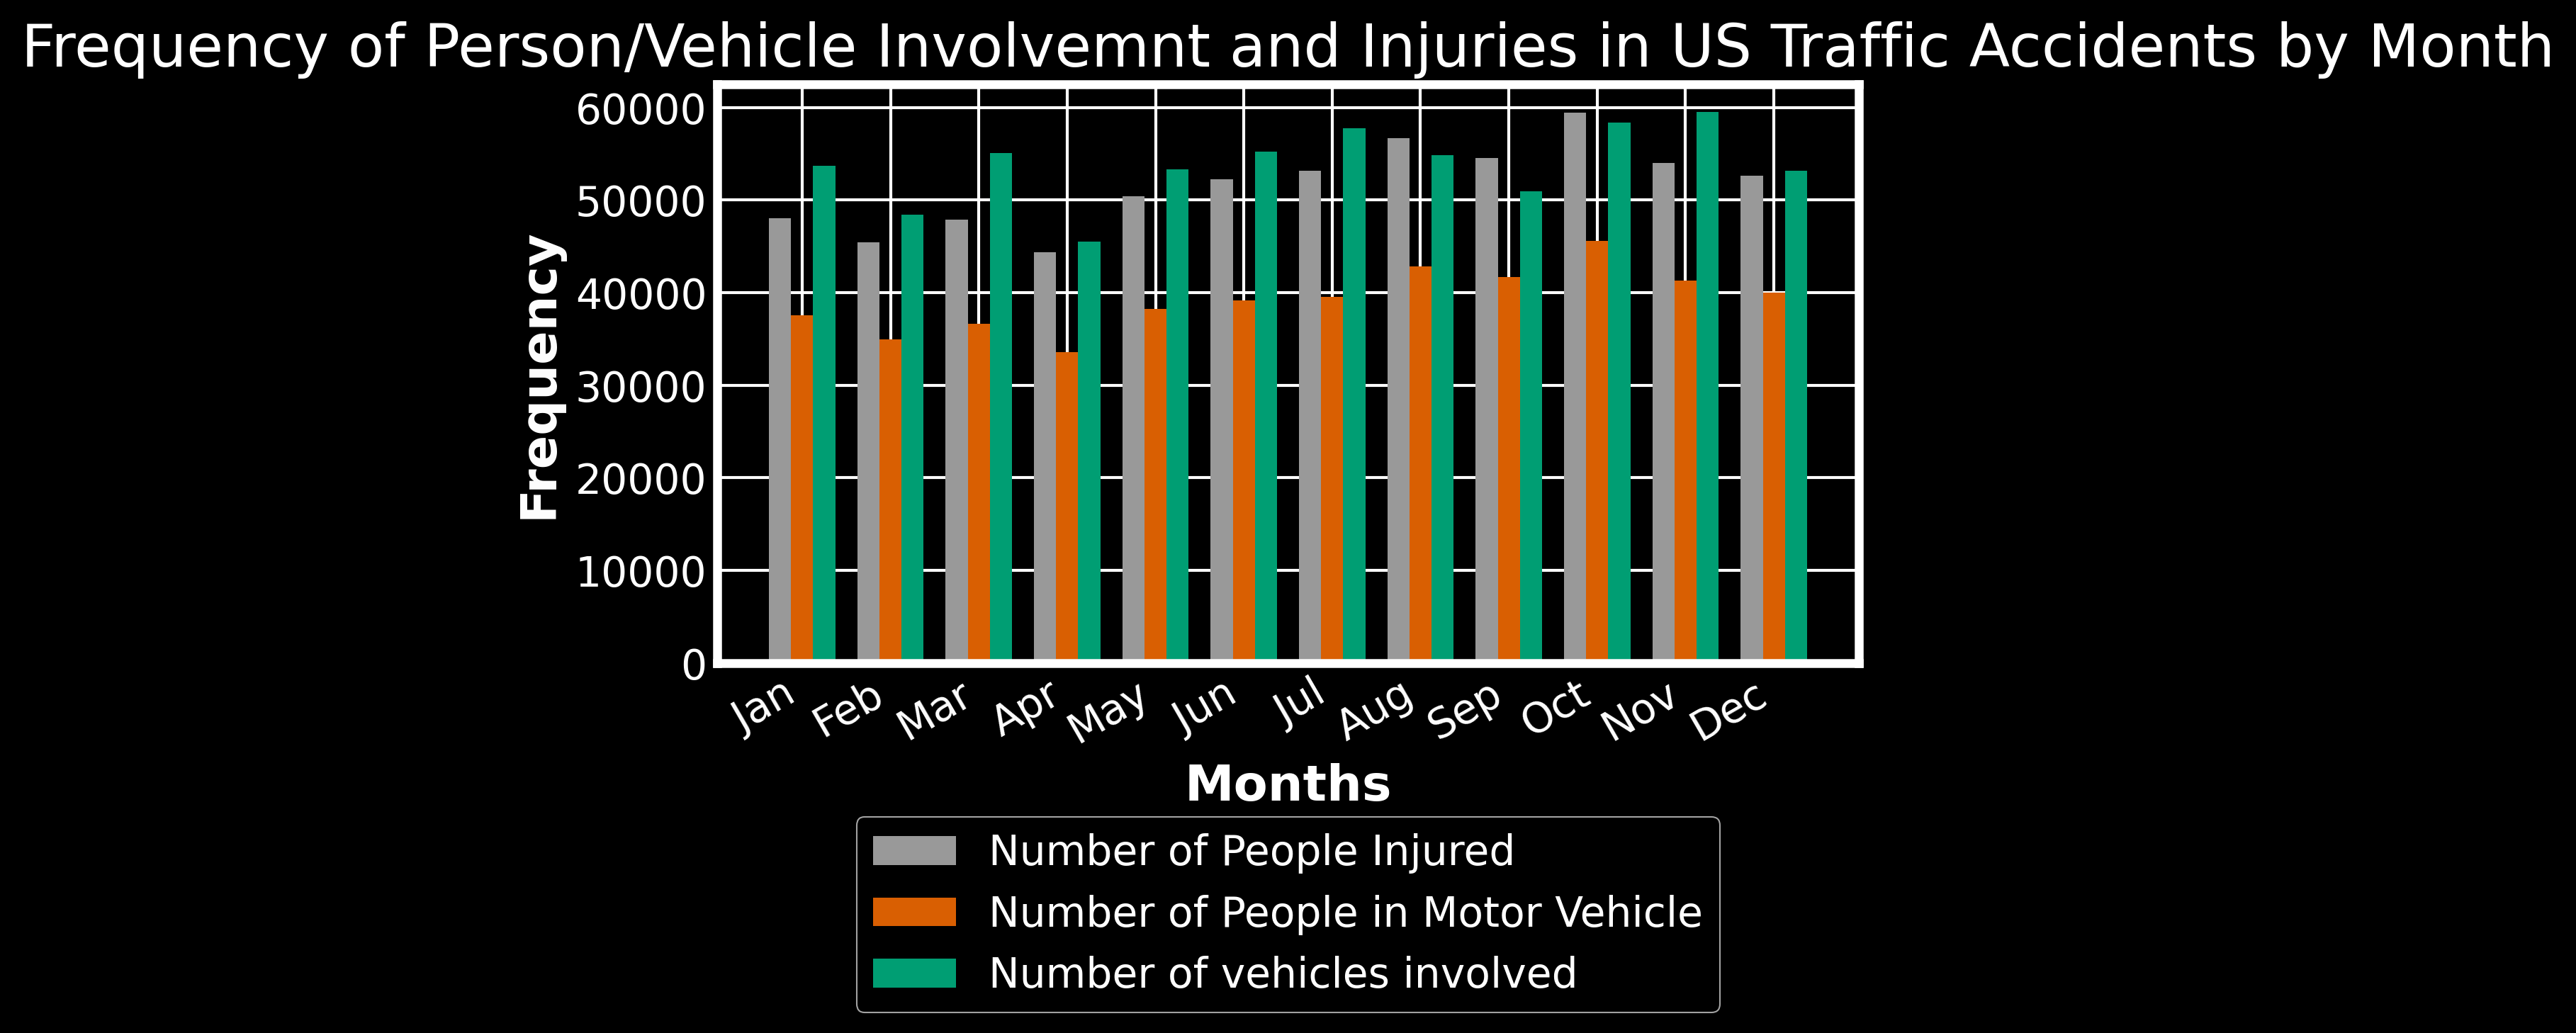

In [56]:
f = open("USdataset.csv")
months = ["Jan", 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
attributes = {
    'persinmv':[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    've_tot':[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'injured':[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

isHeader = True
for line in f:
    if isHeader:
        isHeader = False
        continue
    vals = line.rstrip().split(",")
    month = int(vals[8])
    attributes['persinmv'][month-1] += int(vals[5])
    attributes['ve_tot'][month-1] += int(vals[2])
    attributes['injured'][month-1] += int(vals[7])

barWidth = 0.25
r = np.arange(12)
r2 = r + barWidth
r3 = r2 + barWidth

plt.style.use('dark_background')
fig, ax = plt.subplots(dpi=300, layout='constrained')
ax.bar(r, attributes['persinmv'], color='#999999', width=barWidth, label='Number of People Injured')
ax.bar(r2, attributes['ve_tot'], color='#d95f02', width=barWidth, label='Number of People in Motor Vehicle')
ax.bar(r3, attributes['injured'], color='#009e73', width=barWidth, label='Number of vehicles involved')


ax.set_xlabel('Months', fontweight='bold')
ax.set_xticks(r + barWidth)
ax.set_xticklabels(months)
fig.autofmt_xdate()
ax.set_ylabel('Frequency', fontweight="bold")
ax.set_title('Frequency of Person/Vehicle Involvemnt and Injuries in US Traffic Accidents by Month')
fig.legend(loc='outside lower center')

plt.show()
f.close()

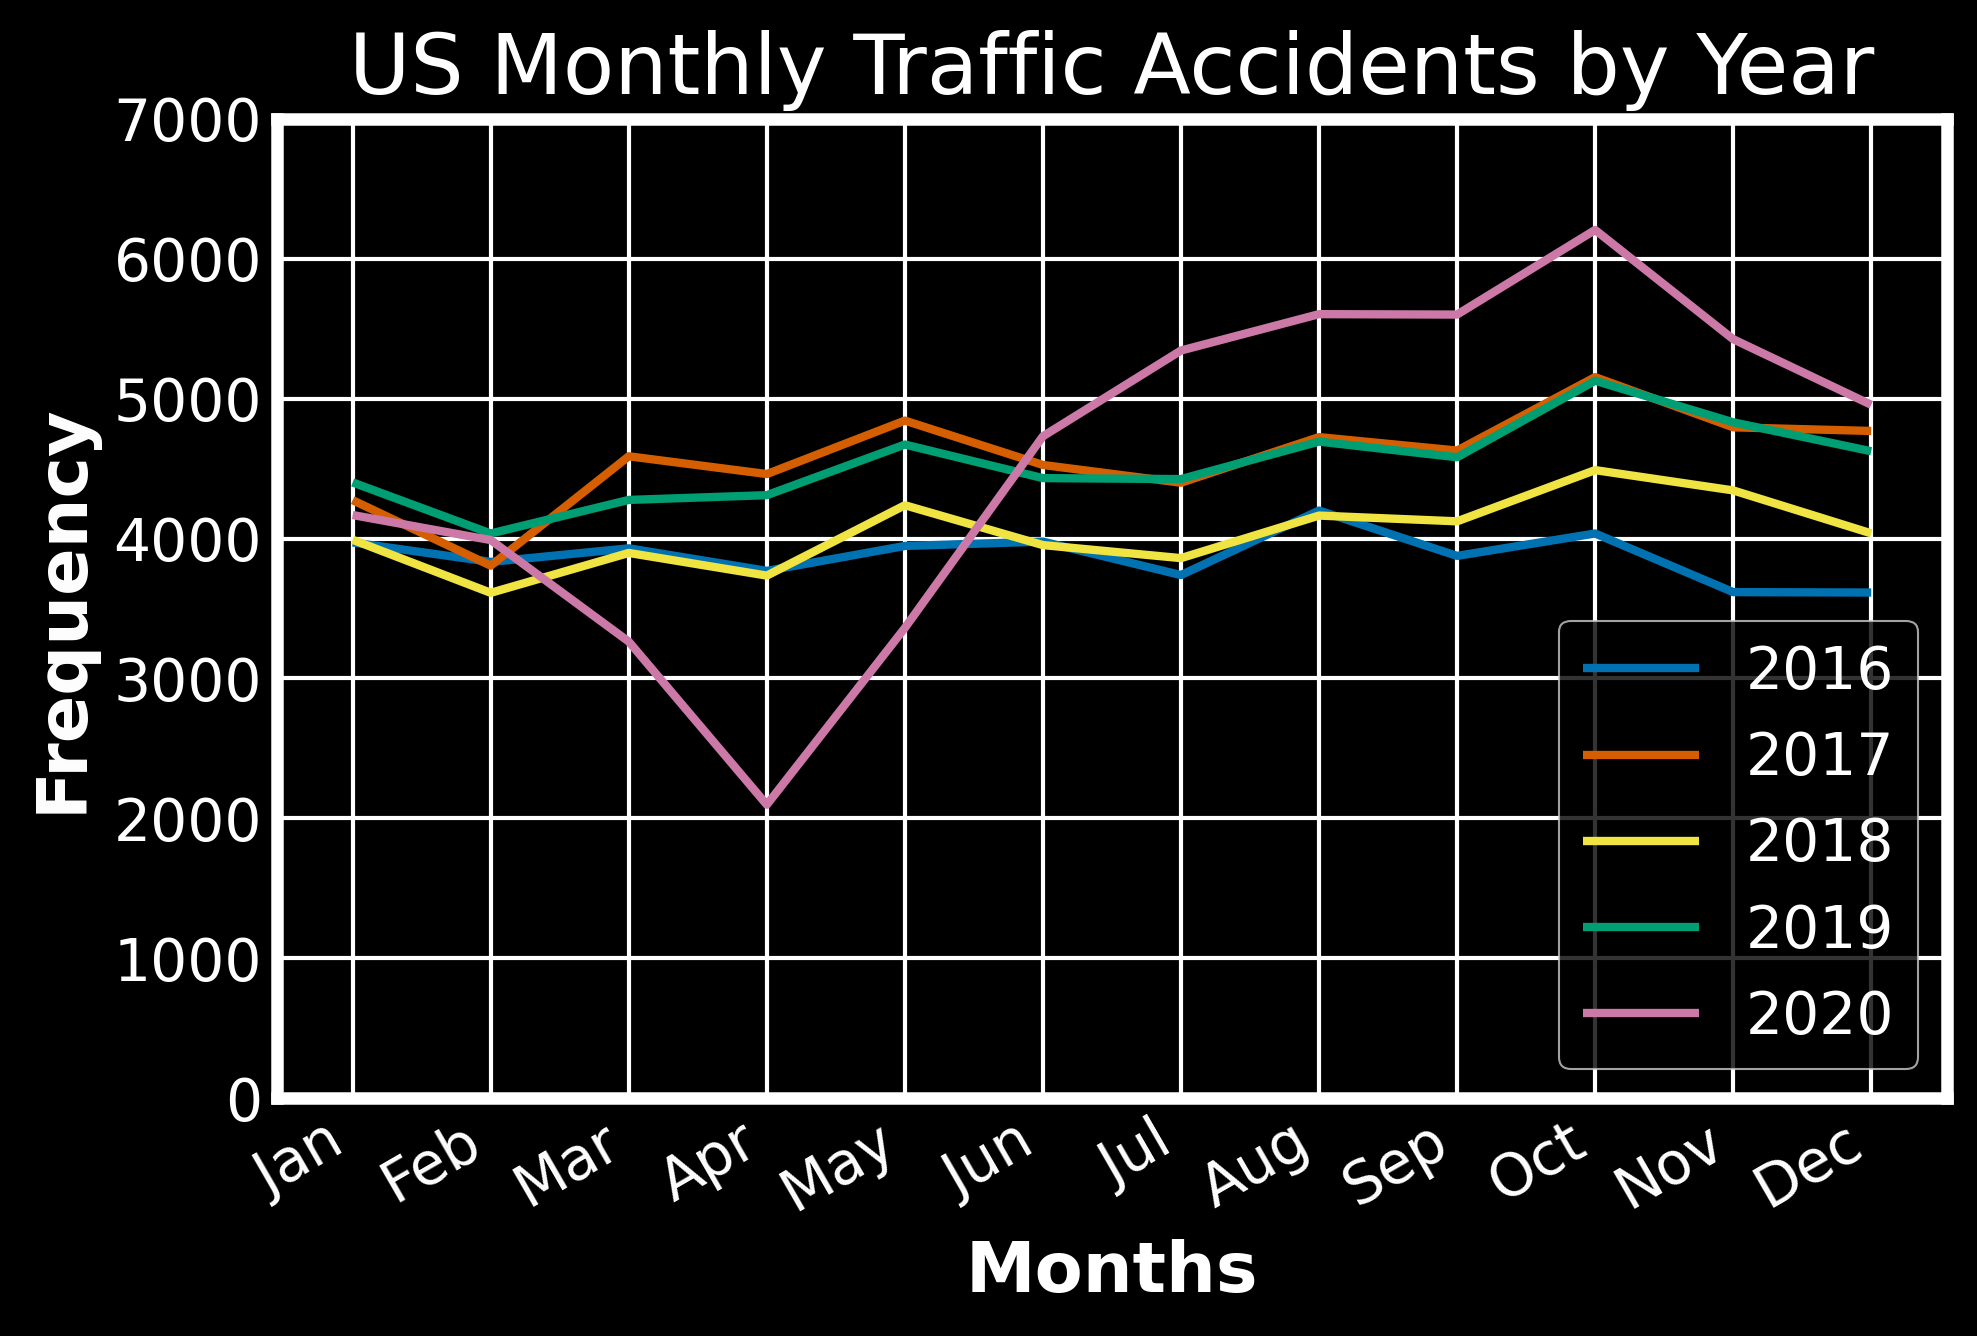

In [57]:
#number of crashes per year

f = open("USdataset.csv")
months = ["Jan", "Feb","Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
years = {
    2016:[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    2017:[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    2018:[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    2019:[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    2020:[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

isHeader = True
for line in f:
    if isHeader:
        isHeader = False
        continue
    vals=line.rstrip().split(",")
    month = int(vals[8])
    year = int(vals[9])
    if month == 99:
        continue
    years[year][month-1] += 1

plt.style.use('dark_background')
fig, ax = plt.subplots(dpi=300)

ax.plot(months, years[2016], color='#0072B2', label="2016", linewidth=2)
ax.plot(months, years[2017], color='#D55E00', label="2017", linewidth=2)
ax.plot(months, years[2018], color='#F0E442', label="2018", linewidth=2)
ax.plot(months, years[2019], color='#009E73', label="2019", linewidth=2)
ax.plot(months, years[2020], color='#CC79A7', label="2020", linewidth=2)

ax.set_xlabel('Months', fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")
ax.set_title("US Monthly Traffic Accidents by Year")
ax.set_ylim(bottom=0, top=7000)
fig.autofmt_xdate()
ax.legend(loc='best')

plt.show()
f.close()

Here there is a notable drop in April 2020 which is likely due to COVID-19 lockdowns followed by a significant increase for the rest of the year after June 2020.